<a href="https://colab.research.google.com/github/chaymaebouabdellah24-tech/SunPath-Predictor/blob/main/SunPath_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
#Installer XGBoost
!pip install xgboost

In [5]:
#Importer les librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

In [6]:
#Charger les datasets
generation = pd.read_csv('Plant_1_Generation_Data.csv')
weather = pd.read_csv('Plant_1_Weather_Sensor_Data.csv')

In [7]:
#Explorer les données
generation.head()
weather.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,4135001,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,4135001,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0


In [8]:
#Convertir les dates
generation['DATE_TIME'] = pd.to_datetime(generation['DATE_TIME'])
weather['DATE_TIME'] = pd.to_datetime(weather['DATE_TIME'])

/tmp/ipykernel_10444/1030277924.py:2: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  generation['DATE_TIME'] = pd.to_datetime(generation['DATE_TIME'])


In [9]:
#faire le megre
data = pd.merge(generation, weather, on='DATE_TIME', how='inner')

print(data.shape)

(68774, 12)


In [10]:
#Vérifier le dataset final
data.head()
data.shape

(68774, 12)

In [11]:
#Convertir la date
data['DATE_TIME'] = pd.to_datetime(data['DATE_TIME'])

In [12]:
#Créer des variables temporelles
data['hour'] = data['DATE_TIME'].dt.hour
data['day'] = data['DATE_TIME'].dt.day
data['month'] = data['DATE_TIME'].dt.month

In [13]:
#Choisir les variables (features)
X = data[['IRRADIATION',
          'AMBIENT_TEMPERATURE',
          'MODULE_TEMPERATURE',
          'hour']]

In [14]:
#Variable cible
y = data['AC_POWER']

In [15]:
#Séparer Train / Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
#Linear Regression
lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [17]:
#Evaluation Linear Regression
print("Linear Regression")

print("MAE:", mean_absolute_error(y_test, pred_lr))
print("R2:", r2_score(y_test, pred_lr))

Linear Regression
MAE: 26.2979657748521
R2: 0.9800290556767175


In [18]:
#Random Forest
rf = RandomForestRegressor()

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [19]:
#Evaluation Random Forest
print("Random Forest")

print("MAE:", mean_absolute_error(y_test, pred_rf))
print("R2:", r2_score(y_test, pred_rf))

Random Forest
MAE: 16.39009118331382
R2: 0.9864844151089252


In [20]:
#XGBoost
xgb = XGBRegressor()

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

In [21]:
#Evaluation XGBoost
print("XGBoost")

print("MAE:", mean_absolute_error(y_test, pred_xgb))
print("R2:", r2_score(y_test, pred_xgb))

XGBoost
MAE: 16.633382073934325
R2: 0.986531205412942


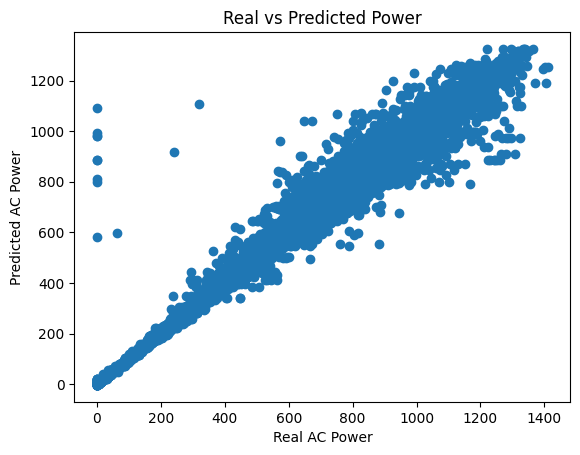

In [22]:
#Visualiser les prédictions
plt.scatter(y_test, pred_xgb)
plt.xlabel("Real AC Power")
plt.ylabel("Predicted AC Power")
plt.title("Real vs Predicted Power")
plt.show()

In [23]:
#Import Deep Learning
import numpy as np
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM
from sklearn.preprocessing import MinMaxScaler

In [24]:
#Normaliser les données
scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

In [25]:
#Transformer les données en séquences
def create_sequences(X, y, time_steps=10):

    Xs = []
    ys = []

    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y.iloc[i + time_steps])

    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(pd.DataFrame(X_scaled), y)

In [26]:
#Split Train/Test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42
)

In [27]:
#Modèle RNN
model_rnn = Sequential()

model_rnn.add(SimpleRNN(50, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
model_rnn.add(Dense(1))

model_rnn.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model_rnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,750 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,801 (10.94 KB)

 Trainable params: 2,801 (10.94 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
#Entrainer le modèle RNN
history_rnn = model_rnn.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
1720/1720 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 16783.6875 - mae: 57.1169 - val_loss: 9272.7959 - val_mae: 46.2346
Epoch 2/10
1720/1720 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 8081.0659 - mae: 41.3859 - val_loss: 8297.8125 - val_mae: 43.7831
Epoch 3/10
1720/1720 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 7759.5088 - mae: 40.1942 - val_loss: 7664.4619 - val_mae: 42.1105
Epoch 4/10
1720/1720 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 7817.5186 - mae: 40.6663 - val_loss: 6741.1909 - val_mae: 36.8072
Epoch 5/10
1720/1720 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 7499.8032 - mae: 39.5187 - val_loss: 6728.3286 - val_mae: 36.7390
Epoch 6/10
1720/1720 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 7346.3003 - mae: 38.7416 - val_loss: 6602.9077 - val_mae: 36.1293
Epoch 7/10
1720/1720 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 7298.0640 - mae: 38.8540 - val_loss: 6366.5308 - val_mae: 35.8354
Epoch 8/10
1720/1720 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 7016.6992 - mae: 37.8509 - val_loss: 7295

In [29]:
#Modèle LSTM
model_lstm = Sequential()

model_lstm.add(LSTM(50, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
model_lstm.add(Dense(1))

model_lstm.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model_lstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        11,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,051 (43.17 KB)

 Trainable params: 11,051 (43.17 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
#Entrainer le modèle LSTM
history_lstm = model_lstm.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/10
1720/1720 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - loss: 17818.5684 - mae: 57.7076 - val_loss: 6990.3296 - val_mae: 36.6593
Epoch 2/10
1720/1720 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 7545.7632 - mae: 39.7098 - val_loss: 6786.3960 - val_mae: 36.8960
Epoch 3/10
1720/1720 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 7318.8789 - mae: 38.8479 - val_loss: 6525.6733 - val_mae: 37.2738
Epoch 4/10
1720/1720 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 7198.0728 - mae: 38.5727 - val_loss: 6785.6660 - val_mae: 37.1446
Epoch 5/10
1720/1720 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 7040.4316 - mae: 38.0804 - val_loss: 6795.5083 - val_mae: 38.0799
Epoch 6/10
1720/1720 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 6722.5112 - mae: 36.9637 - val_loss: 5841.2129 - val_mae: 32.8849
Epoch 7/10
1720/1720 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - loss: 6498.1704 - mae: 36.0215 - val_loss: 6483.2007 - val_mae: 38.9528
Epoch 8/10
1720/1720 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 6253.9258 - mae: 35.1816 - val_lo

In [31]:
#Faire une prédiction
predictions = model_lstm.predict(X_test)

print(predictions[:10])

430/430 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
[[1.2071643e+03]
 [3.0141885e+02]
 [6.5502991e+02]
 [3.8044238e+02]
 [1.1300074e+03]
 [1.7503831e+02]
 [3.5549662e+00]
 [3.2888217e+02]
 [4.2867464e-01]
 [1.8322389e+00]]


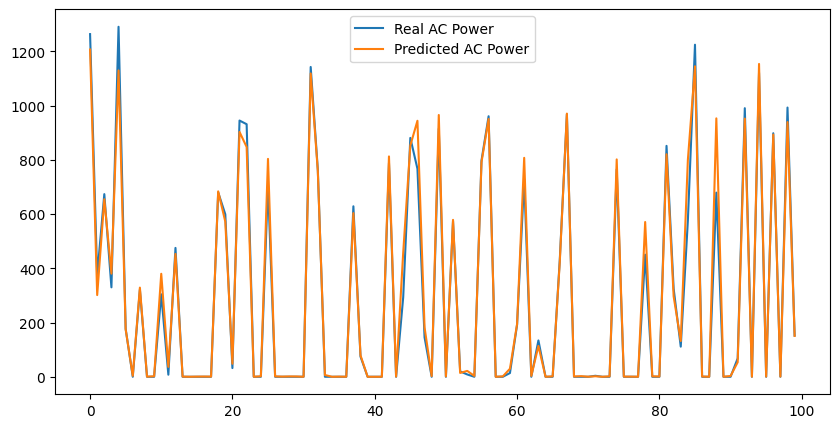

In [32]:
#Graphique pour la soutenance
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(y_test[:100], label="Real AC Power")
plt.plot(predictions[:100], label="Predicted AC Power")

plt.legend()
plt.show()

In [33]:
# =========================
#  PREDICTION FINALE
# =========================

import numpy as np

#  nouvelles valeurs (tu peux changer)
temp = 30
sun = 800
hum = 20
irr = 10

new_data = [[temp, sun, hum, irr]]

print(" Données :", new_data)

# =========================
#  MODELES ML
# =========================

print(" Random Forest :", rf.predict(new_data))
print(" Linear Regression :", lr.predict(new_data))
print(" XGBoost :", xgb.predict(new_data))


# =========================
#  MODELES DL (LSTM + RNN)
# =========================

#  normalisation
new_data_scaled = scaler.transform(new_data)

#  transformation en 3D
new_data_scaled = np.reshape(new_data_scaled, (1, 1, new_data_scaled.shape[1]))

print(" LSTM :", model_lstm.predict(new_data_scaled))
print(" RNN :", model_rnn.predict(new_data_scaled))


# =========================
#  FIN
# =========================

 Données : [[30, 800, 20, 10]]
 Random Forest : [1229.13866927]
 Linear Regression : [36456.14461707]
 XGBoost : [1238.461]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
 LSTM : [[1.7214863]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
 RNN : [[41.864826]]


In [34]:
print(dir())

['Dense', 'In', 'LSTM', 'LinearRegression', 'MinMaxScaler', 'Out', 'RandomForestRegressor', 'Sequential', 'SimpleRNN', 'X', 'XGBRegressor', 'X_scaled', 'X_seq', 'X_test', 'X_train', '_', '_10', '_7', '__', '___', '__builtin__', '__builtins__', '__doc__', '__loader__', '__name__', '__package__', '__spec__', '_dh', '_exit_code', '_i', '_i1', '_i10', '_i11', '_i12', '_i13', '_i14', '_i15', '_i16', '_i17', '_i18', '_i19', '_i2', '_i20', '_i21', '_i22', '_i23', '_i24', '_i25', '_i26', '_i27', '_i28', '_i29', '_i3', '_i30', '_i31', '_i32', '_i33', '_i34', '_i4', '_i5', '_i6', '_i7', '_i8', '_i9', '_ih', '_ii', '_iii', '_oh', 'create_sequences', 'data', 'exit', 'generation', 'get_ipython', 'history_lstm', 'history_rnn', 'hum', 'irr', 'lr', 'mean_absolute_error', 'model_lstm', 'model_rnn', 'new_data', 'new_data_scaled', 'np', 'pd', 'plt', 'pred_lr', 'pred_rf', 'pred_xgb', 'predictions', 'quit', 'r2_score', 'rf', 'scaler', 'sun', 'temp', 'tf', 'train_test_split', 'weather', 'xgb', 'y', 'y_seq',

In [35]:
import pickle

pickle.dump(rf, open("rf.pkl", "wb"))